<a href="https://colab.research.google.com/github/Madelavishnu/Pytorch/blob/main/Pytorch_EXP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pytorch workflow Fundamentals

## What We are Going To Cover

* Get data ready(turn into tensors)
* Build /pick the pretrained model
* Fit the Model and Make a prediction
* Evaluate the Model
* Improve Through experimental
* Save and Reload Your TrainedModel
*

In [2]:
import sys
sys.executable

'/usr/bin/python3'

In [3]:
import torch
import torch.nn as nn         # nn contains all pytorch building blocks for neural networks
import matplotlib.pyplot as plt

# check pytorch version
torch.__version__

'2.9.0+cu126'

### DATA (preparing and loading)
Data can be anything... ML
* Excel Speadsheet
* image of any kind
* videos
* images
* text ...........

ML is a game of 2 parts:
* get data into numerical representation
* build model to learn patterns in numerical representation

In [4]:
# we'll use linear regression to make straight line with known paramete rs

weight = 0.7
bias = 0.3
X = torch.arange(0,1,0.02).unsqueeze(dim = 1)
y = weight * X + bias

len(X), len(y)    # 50,50

(50, 50)

#### spliting the data into training and testing sets

In [5]:
# crete train/test split

train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split] , y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(X_test) , len(y_train), len(y_test)           # 40,40,10,10


(40, 10, 40, 10)

In [6]:
# how might we better visualize our data?

def plot_predictions(train_data = X_train,
                    train_labels = y_train,
                    test_data = X_test,
                    test_labels = y_test,
                    predictions = None):
    plt.figure(figsize = (10,7))

    plt.scatter(train_data,train_labels, c ='r', s = 4, label = "training data")
    plt.scatter(test_data, test_labels, c = 'b', s = 4, label = "testing data")

    #are there predictions>
    if predictions is not None:
        plt.scatter(test_data, predictions , c = 'r', s = 4, label = "predictions")

    plt.legend(prop ={"size": 14});

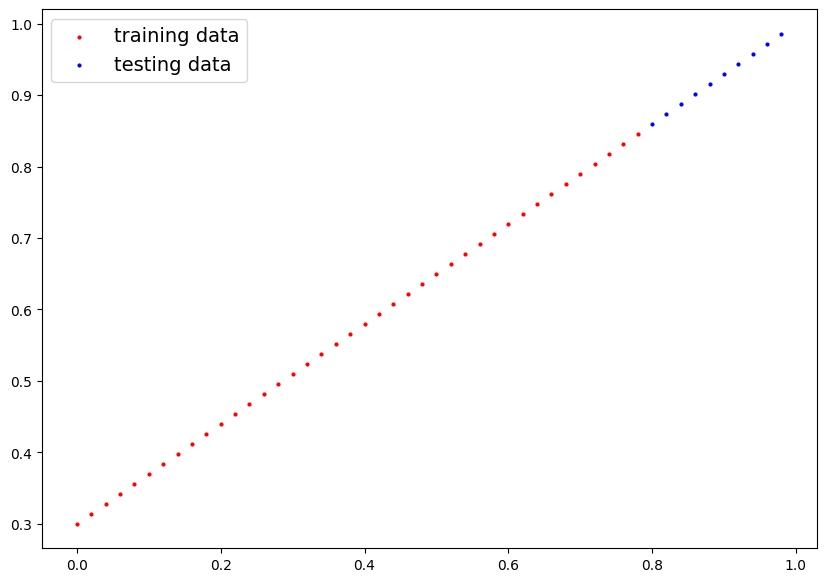

In [7]:
plot_predictions();   # you see one linear graph

### wow look your data

## Build a Model

#### what our model does
* start with random values
* look at trainng data and adjustion the random values to better represent ideal values

how does it do so?
* Gradient descent
* back propogation

In [8]:
# Create linear regression model class
'''
nn.Linear
nn.Conv2d
nn.LSTM
nn.Transformer
Custom models → must inherit from nn.Module'''

from torch import nn

class LinearRegressionModel(nn.Module):   # <- almost everthing in pytorch inherhits from nn.Module
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,
                                                requires_grad = True,
                                                dtype = torch.float))
        self.bias = nn.Parameter(torch.randn(1,
                                             requires_grad = True,
                                             dtype = float))
    # forward method to define computation model

    def forward(self, x: torch.Tensor) -> torch.Tensor:# <- x is input data
        return self.weights *x +self.bias    # linear Regression formula


### Pytorch model building essential
* torch.nn - contains all of the buildings for computational graphs
* torch.nn.Parameters - what parameters should our model try and learn
* torch.nn.Module - the base calss for all NN modules
* torch.optim - this where the optimizers in pytorch live , they will help with gradient descent

### Checking the contents of pytorch Model

In [9]:
torch.manual_seed(42)

model_0 = LinearRegressionModel()

list(model_0.parameters())



[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], dtype=torch.float64, requires_grad=True)]

In [10]:
torch.manual_seed(42)
torch.randn(1)

tensor([0.3367])

In [11]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])),
             ('bias', tensor([0.1288], dtype=torch.float64))])

### making predictions  using torch.inference_mode()

Lets see how well it predicts y_test based on x_test

In [12]:
# make predictions

with torch.inference_mode():
    y_preds = model_0(X_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]], dtype=torch.float64)

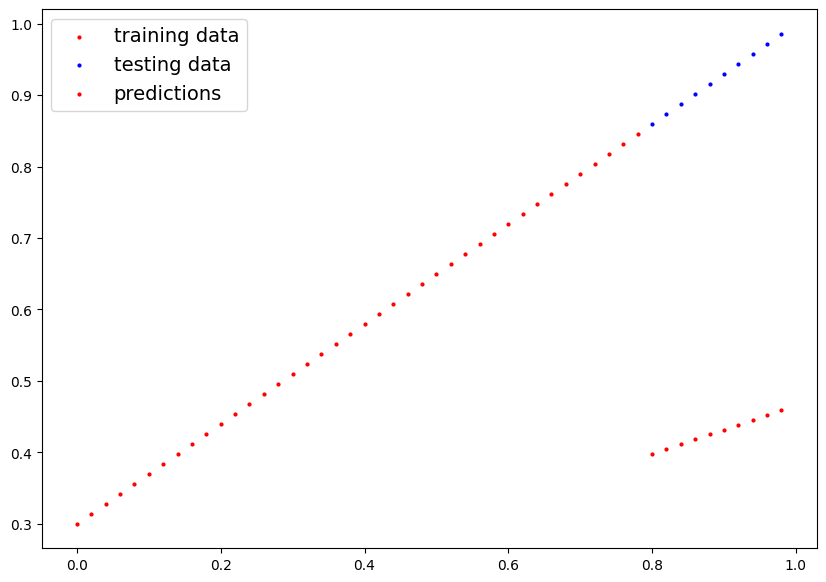

In [13]:
plot_predictions(predictions = y_preds)

### Train Model

whole idea of training model tp amke from unknown parameters to some known parameters

* use loss function it tells how wrong your models predictions are
* use optimizers it adjusts model parameters

In [14]:
# check out our model parameters

model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])),
             ('bias', tensor([0.1288], dtype=torch.float64))])

In [15]:
# setup loss function

loss_fn = nn.L1Loss()

#setup optimizer
optimizer = torch.optim.SGD(params = model_0.parameters(),  # the model parameters you'd like to optimize
                            lr = 0.01)                   # learning rate
# smaller learning rate small change , larger learning rate the larger the change
#EX : 'weights', tensor([0.3367])  if lr 0.0001 it change 0.3369 or something if lr 0.1 means 0.4256 something

#### WHAT LOSS FUNCTION AND OPTIMIZER SHOULD I USE?

its based on the problems you face
for ex: Regression problems--> loss function = nn.L1Loss() and Optimzer = torch.optim.SGD() will suffice

but for Classification problems --> cat or dog like this , you use loss function = nn.BCELoss() (binary cross entropy loss)

### Building a training loop (and testing loop ) in pytorch

a couple of things we neeed in training loop:
* Loop through data
* forward pass to make predictons on data
* calculate the loss
* Optimizer zero grad
* Loss backward - move backward through the network to calculate the gradient of each of parameter of our model with respect of loss (back Propogation)
* Optimizer step (Gradient descent)

In [16]:
# gradient is like a slope like pythogerous therom of hypothesis__

In [17]:
list(model_0.eval().parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], dtype=torch.float64, requires_grad=True)]

In [18]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], dtype=torch.float64, requires_grad=True)]

In [19]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])),
             ('bias', tensor([0.1288], dtype=torch.float64))])

In [20]:
# set parameters
epochs = 1
# 1) an epoch is one loop through the data ( if 100 means we pass data 100 times)

for epoch in range(epochs):
    # set model to training mode
    model_0.train()          # train mode sets all parameters that require gradients  to require gradients

    # 2) Forward pass
    y_pred = model_0(X_train)

    # 3) calculate loss
    loss = loss_fn(y_pred, y_train)
    print(f"Loss : {loss}")

    # 4) optimizer zero grad
    optimizer.zero_grad()

    # 5) perform backpropogation
    loss.backward()

    # 6) step th optimizer
    optimizer.step()  # by default hte optimizer accumilate through loop so... we have to zero them above in step 4 for the next iteration

    # Testing
    model_0.eval()           # turn off gradient tracking

    print(model_0.state_dict())

Loss : 0.3128813517678373
OrderedDict({'weights': tensor([0.3406]), 'bias': tensor([0.1388], dtype=torch.float64)})


#### wow you look at that,  for every time you run the loss values goes down and model is improving

In [21]:
with torch.inference_mode():
    y_pred_new = model_0(X_test)

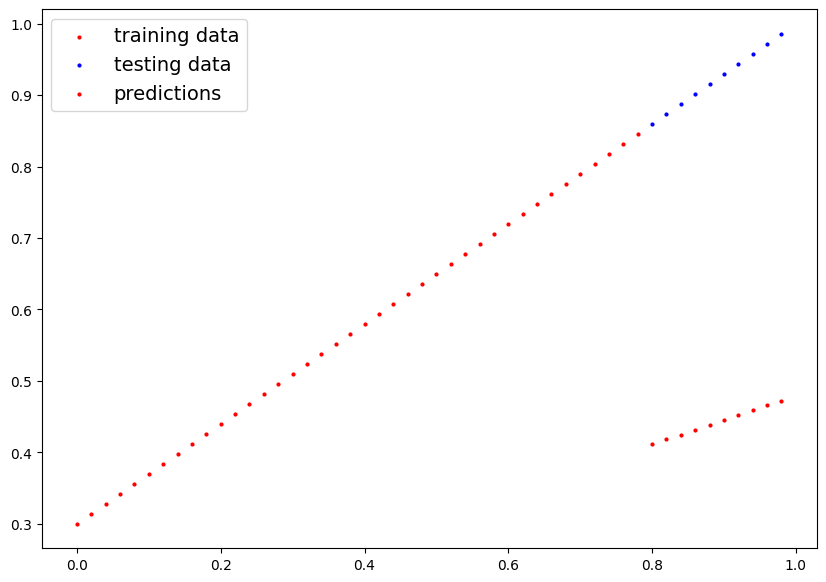

In [22]:
plot_predictions(predictions = y_pred_new);

#### Wow look at that predictons values , its better than before

In [23]:
# now try with 100 epochs
torch.manual_seed(42)

epochs = 100

for epoch in range(epochs):

    model_0.train()

    y_pred = model_0(X_train)

    loss = loss_fn(y_pred, y_train)
    print(f"Loss : {loss}")

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    model_0.eval()

    print(model_0.state_dict())

Loss : 0.3013603568452254
OrderedDict({'weights': tensor([0.3445]), 'bias': tensor([0.1488], dtype=torch.float64)})
Loss : 0.28983935760360513
OrderedDict({'weights': tensor([0.3484]), 'bias': tensor([0.1588], dtype=torch.float64)})
Loss : 0.27831836296039
OrderedDict({'weights': tensor([0.3523]), 'bias': tensor([0.1688], dtype=torch.float64)})
Loss : 0.2667973651972443
OrderedDict({'weights': tensor([0.3562]), 'bias': tensor([0.1788], dtype=torch.float64)})
Loss : 0.25527636870302556
OrderedDict({'weights': tensor([0.3601]), 'bias': tensor([0.1888], dtype=torch.float64)})
Loss : 0.24375537187120244
OrderedDict({'weights': tensor([0.3640]), 'bias': tensor([0.1988], dtype=torch.float64)})
Loss : 0.23223437601726796
OrderedDict({'weights': tensor([0.3679]), 'bias': tensor([0.2088], dtype=torch.float64)})
Loss : 0.220713377613838
OrderedDict({'weights': tensor([0.3718]), 'bias': tensor([0.2188], dtype=torch.float64)})
Loss : 0.2091923824118293
OrderedDict({'weights': tensor([0.3757]), 'bi

tensor([[0.8143],
        [0.8259],
        [0.8375],
        [0.8491],
        [0.8607],
        [0.8723],
        [0.8839],
        [0.8955],
        [0.9071],
        [0.9187]], dtype=torch.float64)


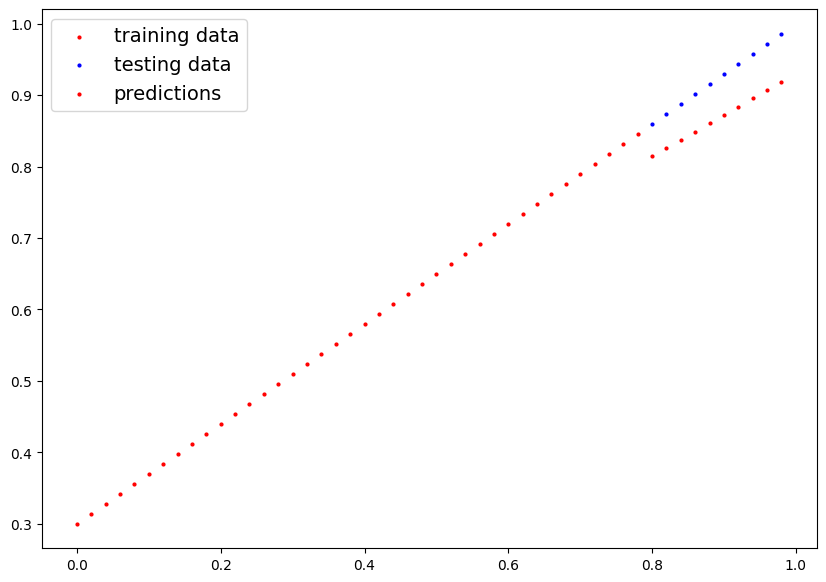

In [24]:
with torch.inference_mode(): # turn offs gradient tracking and a couple more things behind
    # with torch.no_grad() : you may also see torch.no_grad() in older pytorch code

    y_pred_new = model_0(X_test)
    print(y_pred_new)

plot_predictions(predictions = y_pred_new);

### look at that by increasing epochs prediction value change

here you for every 10 epochs model is improving and loss is decresing

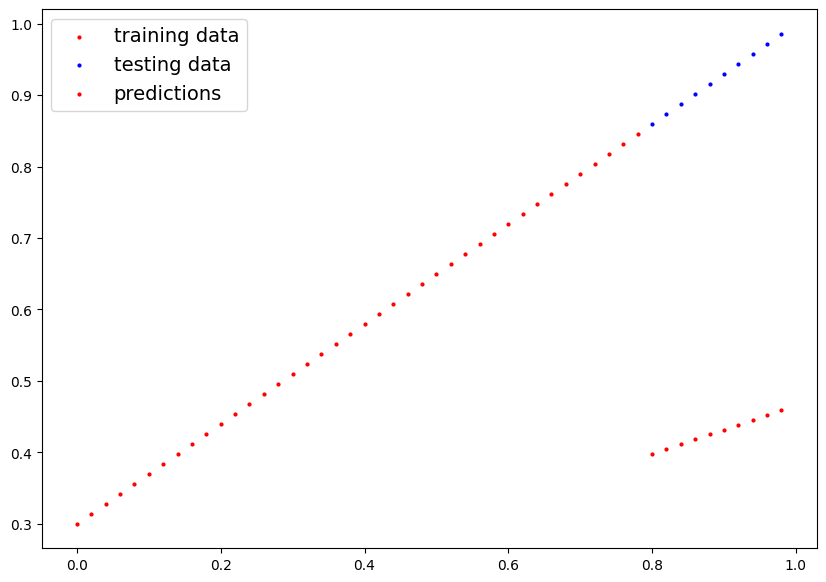

In [25]:
plot_predictions(predictions = y_preds);

#### look how the predictions goes between before and after one

In [26]:
torch.manual_seed(42)

epochs = 200

test_loss_values = []
loss_values = []
epoch_count = []


for epoch in range(epochs):
  model_0.train()
  y_pred = model_0(X_train)
  loss = loss_fn(y_pred, y_train)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_0.eval()
  with torch.inference_mode():
    test_pred = model_0(X_test)
    test_loss = loss_fn(test_pred, y_test)

  if epoch%10== 0:
    epoch_count.append(epoch)
    loss_values.append(loss)
    test_loss_values.append(test_loss)
    print(f"Epoch: {epoch} | Loss: {loss} | Test Loss: {test_loss}")

    model_0.state_dict()




Epoch: 0 | Loss: 0.02410999099424655 | Test Loss: 0.05536150045346751
Epoch: 10 | Loss: 0.020677652197677344 | Test Loss: 0.04777593738984605
Epoch: 20 | Loss: 0.017245167735392086 | Test Loss: 0.039503480982298944
Epoch: 30 | Loss: 0.01380635741724246 | Test Loss: 0.03123103351544878
Epoch: 40 | Loss: 0.010375692593093677 | Test Loss: 0.02364547343205945
Epoch: 50 | Loss: 0.006941534787030764 | Test Loss: 0.015373022984976937
Epoch: 60 | Loss: 0.0035027254933359354 | Test Loss: 0.007100572537894423
Epoch: 70 | Loss: 0.002589577798063901 | Test Loss: 0.008446830559258345
Epoch: 80 | Loss: 0.002589577798063901 | Test Loss: 0.008446830559258345
Epoch: 90 | Loss: 0.002589577798063901 | Test Loss: 0.008446830559258345
Epoch: 100 | Loss: 0.002589577798063901 | Test Loss: 0.008446830559258345
Epoch: 110 | Loss: 0.002589577798063901 | Test Loss: 0.008446830559258345
Epoch: 120 | Loss: 0.002589577798063901 | Test Loss: 0.008446830559258345
Epoch: 130 | Loss: 0.002589577798063901 | Test Loss: 0

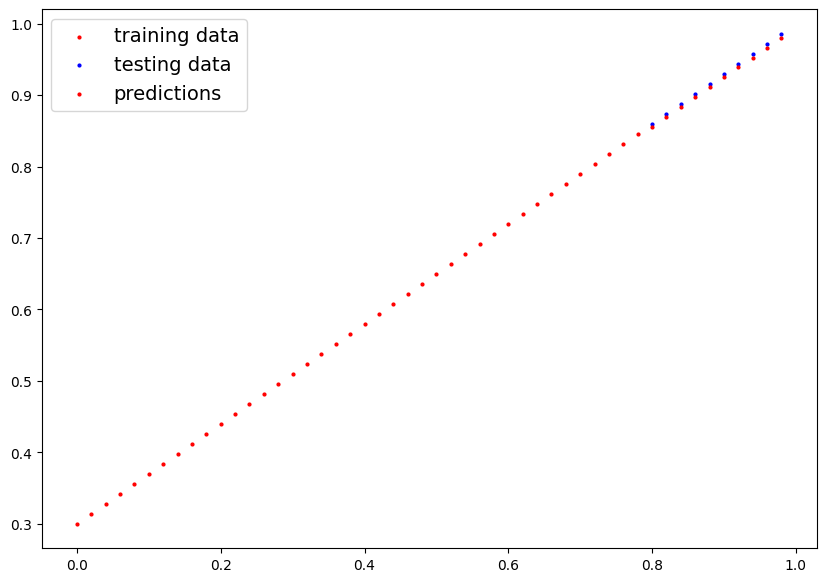

In [27]:
plot_predictions(predictions = test_pred)

In [28]:
loss_values, test_loss_values

([tensor(0.0241, dtype=torch.float64, grad_fn=<MeanBackward0>),
  tensor(0.0207, dtype=torch.float64, grad_fn=<MeanBackward0>),
  tensor(0.0172, dtype=torch.float64, grad_fn=<MeanBackward0>),
  tensor(0.0138, dtype=torch.float64, grad_fn=<MeanBackward0>),
  tensor(0.0104, dtype=torch.float64, grad_fn=<MeanBackward0>),
  tensor(0.0069, dtype=torch.float64, grad_fn=<MeanBackward0>),
  tensor(0.0035, dtype=torch.float64, grad_fn=<MeanBackward0>),
  tensor(0.0026, dtype=torch.float64, grad_fn=<MeanBackward0>),
  tensor(0.0026, dtype=torch.float64, grad_fn=<MeanBackward0>),
  tensor(0.0026, dtype=torch.float64, grad_fn=<MeanBackward0>),
  tensor(0.0026, dtype=torch.float64, grad_fn=<MeanBackward0>),
  tensor(0.0026, dtype=torch.float64, grad_fn=<MeanBackward0>),
  tensor(0.0026, dtype=torch.float64, grad_fn=<MeanBackward0>),
  tensor(0.0026, dtype=torch.float64, grad_fn=<MeanBackward0>),
  tensor(0.0026, dtype=torch.float64, grad_fn=<MeanBackward0>),
  tensor(0.0026, dtype=torch.float64, gr

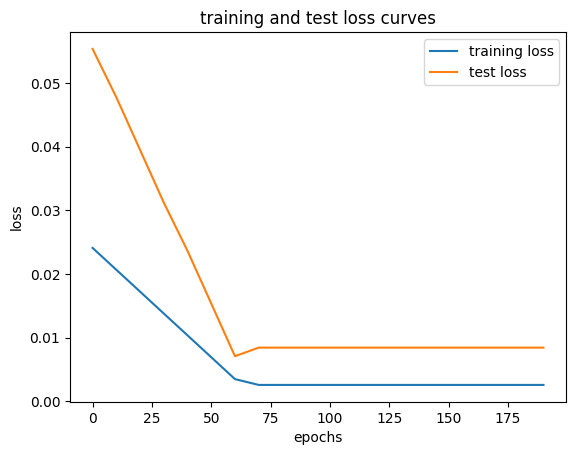

In [36]:
import matplotlib.pyplot as plt

# Convert tensor lists to Python lists of numbers for plotting
plot_loss_values = [loss.item() for loss in loss_values]
plot_test_loss_values = [loss.item() for loss in test_loss_values]

plt.plot(epoch_count, plot_loss_values, label = "training loss")
plt.plot(epoch_count, plot_test_loss_values, label = "test loss")
plt.title("training and test loss curves")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()
plt.show()